# Loading Data

## Importing Libraries and Reading .csv file

In [284]:
###pip install libraries needed
%pip install seaborn scikit-learn


  Using cached scikit_learn-1.9.1-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached scipy-1.18.1-cp314-cp314-win_amd64.whl.metadata (61 kB)
  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached narwhals-2.26.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.7.0-py3-none-any.whl.metadata (24 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
Using cached scikit_learn-1.9.1-cp314-cp314-win_amd64.whl (8.4 MB)
Using cached joblib-1.6.0-py3-none-any.whl (306 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
Using cached narwhals-2.26.0-py3-none-any.whl (474 kB)
Using cached scipy-1.18.1-cp314-cp314-win_amd64.whl (37.4 MB)
Using cached threadpoolctl-3.7.0-py3-none-any.whl (26 kB)

   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]
   ------ -

In [265]:
###importing libraries needed for loading and engineering###
import numpy as np, pandas as pd, datetime as dt, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path

%matplotlib inline

timezone = 'America/Los_Angeles'


Bike Data:

In [266]:
bike_df = pd.read_csv('scraped_data/fremont_bridge_counter.csv')
###convert all to utc then back to localized timezone 
bike_df.date = pd.to_datetime(bike_df.date, utc=True).dt.tz_convert(timezone)


Weather Data:

In [267]:
weather_df = pd.read_csv('scraped_data/weather.csv')

###convert to common timezone to merge with bike data 
weather_df.date = pd.to_datetime(weather_df.date, utc=True).dt.tz_convert(timezone)

cat_cols = weather_df.select_dtypes(str).columns.to_list()
for col in cat_cols:
    weather_df[col] = pd.Categorical(weather_df[col])

weather_df.dtypes

dt                                            int64
temp                                        float64
feels_like                                  float64
pressure                                      int64
humidity                                      int64
dew_point                                   float64
uvi                                           int64
clouds                                        int64
visibility                                    int64
wind_speed                                  float64
wind_deg                                      int64
wind_gust                                   float64
date            datetime64[us, America/Los_Angeles]
weather_main                               category
weather_desc                               category
rain_1hr_mm                                 float64
snow_1hr_mm                                 float64
dtype: object

Merging Data:

In [268]:
merged_df = pd.merge(bike_df, weather_df, on='date').drop_duplicates()

## Data Visualizations

In [269]:
###lets select data from 3 days
sample = merged_df.iloc[4000:4072].reset_index(drop=True)


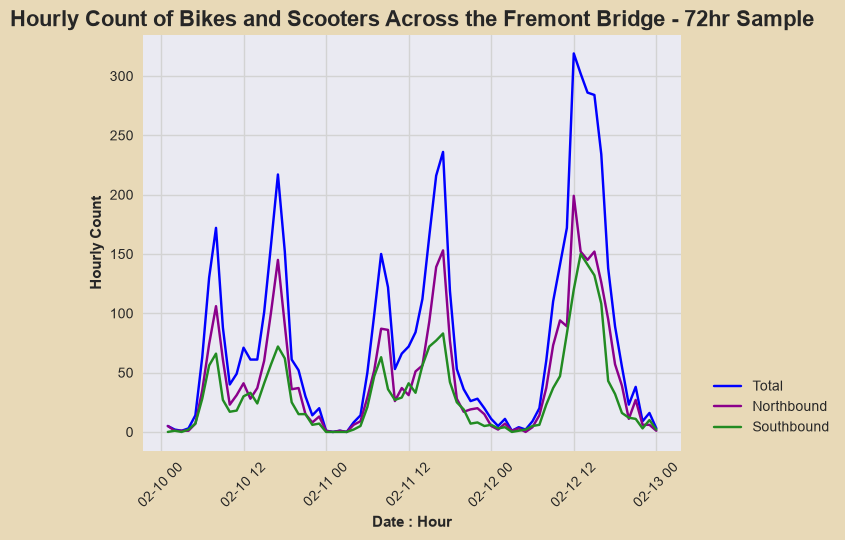

In [270]:
plt.style.use(style="seaborn-v0_8")
plt.figure().set_facecolor("#e8d9b7")

plt.plot(sample['date'], sample['fremont_bridge'], color='blue')
plt.plot(sample['date'], sample['fremont_bridge_nb'], color='darkmagenta')
plt.plot(sample['date'], sample['fremont_bridge_sb'], color='forestgreen')
plt.xticks(rotation=45)

plt.xlabel('Date : Hour', fontweight='bold')
plt.ylabel('Hourly Count', fontweight='bold')

plt.grid(color='lightgray')
plt.legend(labels=['Total','Northbound','Southbound'], bbox_to_anchor=(1.3,.2))
plt.title('Hourly Count of Bikes and Scooters Across the Fremont Bridge - 72hr Sample', fontsize=16, fontweight='bold')

plt.savefig('figs/total_count_sample')

plt.tight_layout()
plt.show()

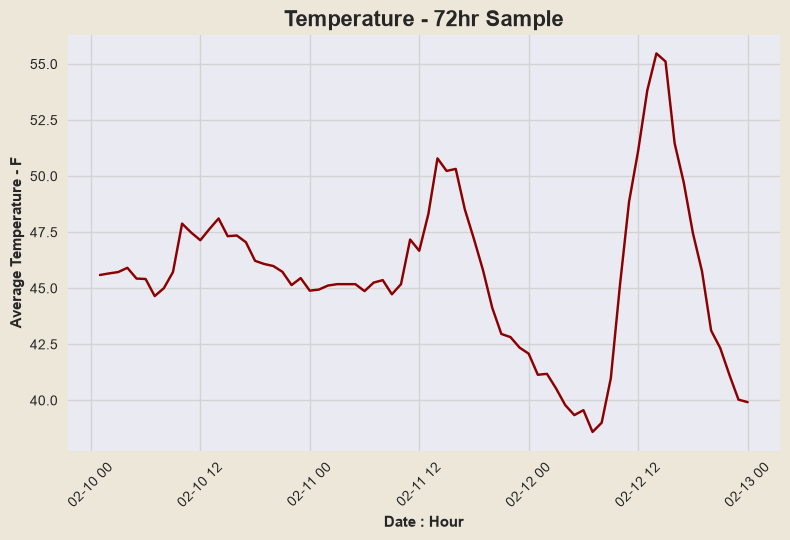

In [271]:
plt.style.use(style="seaborn-v0_8")
plt.figure().set_facecolor("#e4dbc8a7")

plt.plot(sample['date'], sample['temp'], color='darkred')

plt.xticks(rotation=45)

plt.xlabel('Date : Hour', fontweight='bold')
plt.ylabel('Average Temperature - F', fontweight='bold')

plt.grid(color='lightgray')

plt.title('Temperature - 72hr Sample', fontsize=16, fontweight='bold')

plt.savefig('figs/temp_sample')

plt.tight_layout()
plt.show()

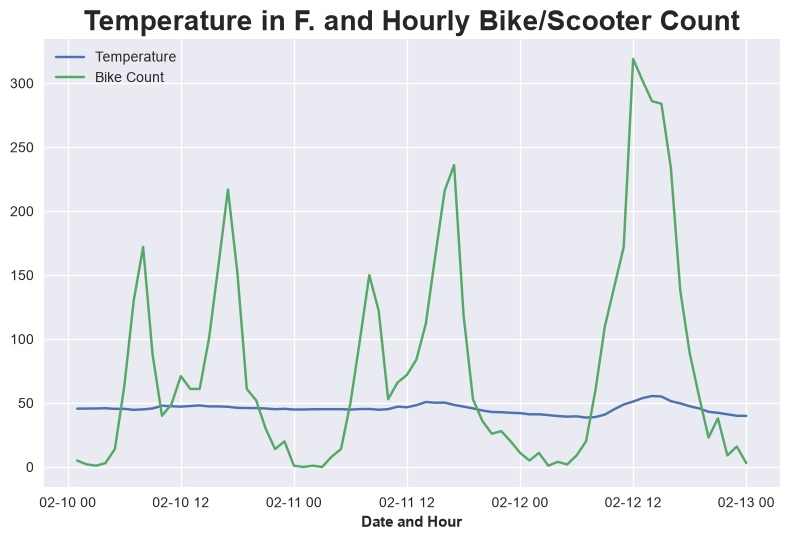

In [272]:
###combine the two plots 

plt.plot(sample['date'], sample[['temp', 'fremont_bridge']])
plt.title('Temperature in F. and Hourly Bike/Scooter Count', fontweight='bold', fontsize=20)
plt.xlabel('Date and Hour', fontweight='bold')
plt.legend(['Temperature', 'Bike Count'])

plt.savefig('figs/temp_hour_raw')
plt.tight_layout()
plt.show()

This does not give us very much information because they are using the same scale. One thing we can try is to min/max normalize the values

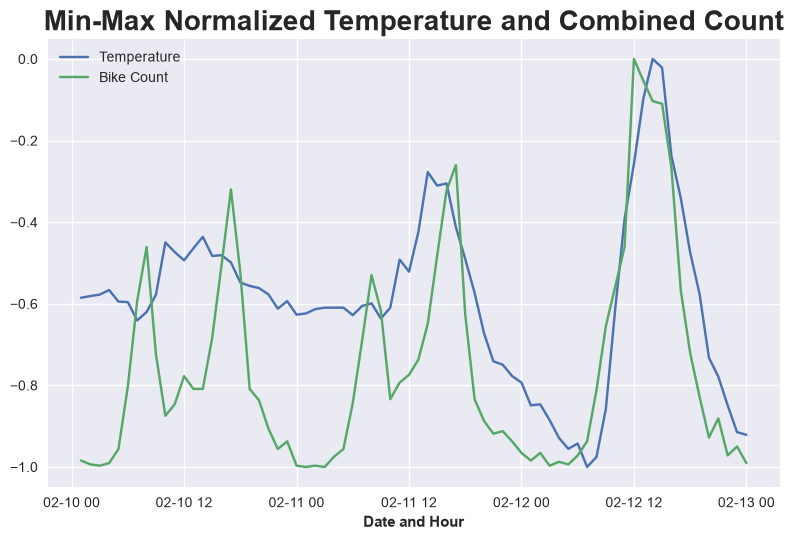

In [273]:
###min max normalization of the two values to compare changes 

for col in ['temp','fremont_bridge']:
    sample[col + '_minmax'] = (sample[col] - sample[col].max()) / (sample[col].max() - sample[col].min())

###Plot combined figure 

plt.plot(sample['date'], sample[['temp_minmax', 'fremont_bridge_minmax']])
plt.title('Min-Max Normalized Temperature and Combined Count', fontweight='bold', fontsize=20)
plt.xlabel('Date and Hour', fontweight='bold')
plt.legend(['Temperature', 'Bike Count'])

plt.savefig('figs/temp_hour_minmax')
plt.tight_layout()
plt.show()

There is much more information to be gleaned from this chart now. Instead of comparing the raw data which operates on two different scales, we use the normalized values in order to see the compared changes in each value according to its min and max values. Here it becomes slightly clearer that temperature might have an effect on bike count data. There is a chance as well that as the night winds down and less people are commutting, so do temperatures. When we analyze the data over the course of months and years instead of days we can get a smoother picture of the seasonal effects of temperature on bike count. 

## Feature Engineering 

### Data Review

We do not have all the features we desire. In fact, there are quite a few I desire to look into, such as the rolling average temp, whether rain fell that day or not, dow of the week, season, etc, etc. We can create these features from the data we already collected in the previous notebook. First, let us review the existing data and features. 

In [274]:
print('Columns/Features:\n' + 35*'-')
for col in merged_df.columns.tolist():
    print(col)

Columns/Features:
-----------------------------------
date
fremont_bridge
fremont_bridge_nb
fremont_bridge_sb
dt
temp
feels_like
pressure
humidity
dew_point
uvi
clouds
visibility
wind_speed
wind_deg
wind_gust
weather_main
weather_desc
rain_1hr_mm
snow_1hr_mm


What are some features we could drop to save space. The northbound and southbound counts are redundant and can be dropped as they are very very correlated with fremont_bridge count. I do not believe pressure is a metric that would affect biking very directly. 

In [275]:
##select columns from removal list that are in the current columns and then drop them 
to_remove = [col for col in ['fremont_bridge_nb', 'fremont_bridge_sb', 'pressure'] if col in merged_df.columns]
merged_df = merged_df.drop(columns=to_remove)


### Data Planning 

<b> What are some features to add? Off the top of my head I think of the following: </b>
- previous hour temp
- previous 24hr temp 
- low 24hr temp 
- high 24hr temp 
- day of week (mon-fri, sat, sun, holiday, federal holiday)
- season 
- time of day category



Maybe:
- rainy binary 
- snowy binary 
- humidity
- counts from other bikeways 
- 72hr bike counts 
- 24hr bike counts

<b> What also could be useful is data related to the pandemic, remote work/jobs in downtown seattle, gas prices, and special events. I do not have the data at this point but I am aware of the sources for each. We can add a simple before or after pandemic binary to control for it. Other features will wait until initial model tests and evaluations. </b>

- pandemic before/after 

To add in the future: 
- gas prices
- dtwn seattle job numbers 
- density 
- bike network coverage 
- special events 
- transit coverage
- road types

<b> In the code segment below we will begin by splitting the data into training and testing fields, then engineer a few of the features on the list above - at least initially. We can always add more in the future! </b>

### Feature Engineering

#### Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split


#### Transforming Features

In [276]:
###lets add some of the features!
###previous and rolling average temp, 24hr low and high
feat_df = merged_df.sort_values('dt')
feat_df['prev_temp'] = feat_df['temp'].shift(1)
feat_df['24hr_avg_temp'] = feat_df['temp'].rolling(window=24, min_periods=4).mean().round(2)
feat_df['24hr_low_temp'] = feat_df['temp'].rolling(window=24, min_periods=4).min()
feat_df['24hr_high_temp'] = feat_df['temp'].rolling(window=24, min_periods=4).max()

###add season category 
def seasonize(date_df):
    doy = date_df.day_of_year
    if (doy >= 90) & (doy < 181):
        return 'spring'
    elif (doy >= 181) & (doy < 273):
            return 'spring'
    elif (doy >= 273) & (doy < 366):
            return 'spring'
    elif (doy >= 90) & (doy < 181):
            return 'spring'
    else:
          return 'NO_SEASON'
    
feat_df['season'] = feat_df['date'].apply(lambda x: seasonize(x))

#### put day of the week options 
dow_map = {
    0 : 'mon',
    1 : 'tue',
    2 : 'wed',
    3 : 'thu',
    4 : 'fri', 
    5 : 'sat',
    6 : 'sun'
}
feat_df['dow'] = feat_df.date.dt.day_of_week.map(dow_map)

####add time of day category 

def tod(date_s):
    hod = date_s.hour
    if np.logical_and((hod+1)%12 >= 0, hod < 5):
        return 'night'
    if np.logical_and(hod >= 5, hod < 9):
        return 'morning'
    if np.logical_and(hod >= 9, hod < 15):
        return 'midday'
    if np.logical_and(hod >= 15, hod < 19):
        return 'afternoon'
    if np.logical_and(hod >= 19, (hod-1)%12 <= 24):
        return 'evening'
    else:
        return 'NO_TIME_OF_DAY'

feat_df['tod'] = feat_df.date.apply(lambda x: tod(x))



##mark down added features 
added_features = feat_df.columns[~feat_df.columns.isin(merged_df.columns)]
print('Added the following features:\n' + 30*'*')
for feat in added_features:
    print(feat)
print(30*'*')

###display new features
feat_df[added_features].iloc[1040:1045]

Added the following features:
******************************
prev_temp
24hr_avg_temp
24hr_low_temp
24hr_high_temp
season
dow
tod
******************************


,prev_temp,24hr_avg_temp,24hr_low_temp,24hr_high_temp,season,dow,tod
85037,44.44,47.76,43.86,49.87,spring,wed,evening
85036,44.38,47.55,43.86,49.87,spring,wed,evening
85035,43.99,47.27,42.53,49.87,spring,wed,evening
85034,42.53,46.95,41.68,49.87,spring,thu,night
85033,41.68,46.66,41.65,49.87,spring,thu,night


Yay! We have completed our initial feature engineering

# Modelling 

## Supervised Learning

### Linear Models

#### Model Set-Up and Fitting

#### Model Predictions and Data Visualizations

#### Evaluation

### Support Vector Machines

#### Model Set-Up and Fitting

#### Model Predictions and Data Visualizations

#### Evaluation

### Nearest Neighbors 

#### Model Set-Up and Fitting

#### Model Predictions and Data Visualizations

#### Evaluation

### Emsemble Models

#### Model Set-Up and Fitting

#### Model Predictions and Data Visualizations

#### Evaluation

## Unsupervised Learning 

### K-means

#### Model Set-Up and Fitting

#### Model Predictions and Data Visualizations

#### Evaluation

### Neural Network Models

#### Model Set-Up and Fitting

#### Model Predictions and Data Visualizations

#### Evaluation